Agentic RAG

In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Annotated, List
from langchain_core.documents import Document

c:\Users\ASUS\.conda\envs\graph-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

Preprocess Data

In [4]:
loader = PyPDFLoader("attention.pdf")
chunks = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 100)
docs = text_splitter.split_documents(chunks)

In [5]:
embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12648\2131500445.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [6]:
db = FAISS.from_documents(docs, embeddings)
retriever = db.as_retriever(k=5)

In [7]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [9]:
rag_prompt = ChatPromptTemplate.from_template(
    """Answer the question based only on the context below.

    Context:
    {context}

    Question: {question}
    """
)

In [10]:
rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)

# Implementing Different Graders in Agentic RAG

Retrival Grader

In [11]:
from pydantic import BaseModel, Field

In [12]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [13]:
doc_grader_llm = llm.with_structured_output(GradeDocuments)

In [14]:
system = """You are a grader checking if a document is relevant to a user’s question.The check has to be done very strictly..  
If the document has words or meanings related to the question, mark it as relevant.  
Give a simple 'yes' or 'no' answer to show if the document is relevant or not."""
    
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [15]:
my_retrieval_grader = grade_prompt | doc_grader_llm

Hallucination Grader

In [16]:
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

In [17]:
hallucination_llm = llm.with_structured_output(GradeHallucinations)

In [18]:
# Prompt
system = """You are a grader checking if an LLM generation is grounded in or supported by a set of retrieved facts.  
Give a simple 'yes' or 'no' answer. 'Yes' means the generation is grounded in or supported by a set of retrieved the facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

In [19]:
hallucinations_grader = hallucination_prompt | hallucination_llm


Answer Grader

In [20]:
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


In [21]:
answer_llm = llm.with_structured_output(GradeAnswer)

In [22]:
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

In [23]:
answer_grader = answer_prompt | answer_llm

Question Re-writer

In [33]:
system = """You are a question re-writer that converts an input question into a better optimized version for vector store retrieval document.  
You are given both a question and a document.  
- First, check if the question is relevant to the document by identifying a connection or relevance between them.  
- If there is a little relevancy, rewrite the question based on the semantic intent of the question and the context of the document.  
- If no relevance is found, simply return this single word "question not relevant." dont return the entire phrase 
Your goal is to ensure the rewritten question aligns well with the document for better retrieval."""

In [34]:
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human","""Here is the initial question: \n\n {question} \n,
             Here is the document: \n\n {documents} \n ,
             Formulate an improved question. if possible other return 'question not relevant'."""
        ),
    ]
)

In [35]:
question_rewriter = re_write_prompt | llm | StrOutputParser()

Final Integration

In [25]:
from typing import List
from typing_extensions import TypedDict
class AgentState(TypedDict):
    question: str
    generation: str
    documents: List[str]
    filter_documents: List[str]
    unfilter_documents: List[str]

Nodes

In [26]:
def retrieve(state: AgentState):
    docs = retriever.invoke(state["question"])

    doc_texts = [doc.page_content for doc in docs]

    return {
        "documents": doc_texts,
        "filter_documents": [],
    }

In [35]:
def grade_documents(state:AgentState):

    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for doc in documents:
        score = my_retrieval_grader.invoke({
            "document": doc.page_content,
            "question": question
        })

        if score.binary_score.lower() == "yes":
            filtered_docs.append(doc)

    return {"documents": filtered_docs}

In [28]:
def grade_hallucination(state: AgentState):
    docs_text = "\n\n".join(state["filter_documents"])

    score = hallucinations_grader.invoke({
        "documents": docs_text,
        "generation": state["generation"]
    })

    return {"hallucination": score.binary_score}

In [32]:
def rewrite_question(state: AgentState):
    docs_text = "\n\n".join(state["filter_documents"])

    new_question = question_rewriter.invoke({
        "question": state["question"],
        "documents": docs_text
    })

    if new_question.strip().lower() == "question not relevant.":
        return {}

    return {"question": new_question}

In [27]:
def generate(state: AgentState):
    context = "\n\n".join(state["filter_documents"])

    generation = rag_chain.invoke({
        "context": context,
        "question": state["question"]
    })

    return {"generation": generation}

Edges

In [29]:
def route_after_doc_grade(state: AgentState):
    if len(state["filter_documents"]) > 0:
        return "generate"
    return "end"

In [ ]:
def route_after_hallucination(state: AgentState):
    if state["hallucination"].lower() == "yes":
        return "final"
    return "rewrite"

GRAPH WORKFLOW

In [37]:
workflow = StateGraph(AgentState)

In [38]:
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("grade_hallucination", grade_hallucination)
workflow.add_node("rewrite", rewrite_question)

workflow.set_entry_point("retrieve")

workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    route_after_doc_grade,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

workflow.add_edge("generate", "grade_hallucination")

workflow.add_conditional_edges(
    "grade_hallucination",
    route_after_hallucination,
    {
        "final": END,
        "rewrite": "rewrite"
    }
)

workflow.add_edge("rewrite", "retrieve")

In [39]:
app = workflow.compile()

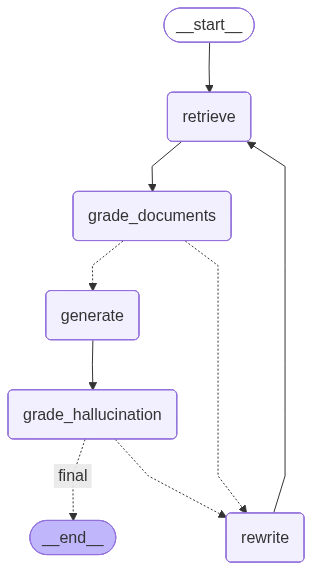

In [40]:
app